# 🔍 Notebook 1 — EDA & Preprocessing
**Malicious URL Detection | ISCX-URL2016**

This notebook covers:
- Loading the dataset
- Exploratory Data Analysis (class distribution, missing values, correlations)
- Data cleaning & preprocessing
- Feature engineering & feature selection (RF importance + correlation filter)



## 0 · Setup & Drive Mount

In [4]:
# Install / upgrade libraries
!pip install -q imbalanced-learn lightgbm optuna seaborn scikit-learn pandas numpy matplotlib

from google.colab import drive
drive.mount('/content/drive')

import os
# ── ⚙️  EDIT THIS PATH to point at your All.csv on Drive ──
DATA_PATH = '/content/drive/MyDrive/ESI TPs/sec_miniProject/Detection_of_Malicious_URLs/Data/All.csv'
SAVE_DIR  = '/content/drive/MyDrive/ESI TPs/sec_miniProject/Detection_of_Malicious_URLs/output/'
os.makedirs(SAVE_DIR, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.9 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1 · Load Dataset

In [5]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (36707, 80)


,Querylength,domain_token_count,path_token_count,avgdomaintokenlen,longdomaintokenlen,avgpathtokenlen,tld,charcompvowels,charcompace,ldl_url,...,SymbolCount_FileName,SymbolCount_Extension,SymbolCount_Afterpath,Entropy_URL,Entropy_Domain,Entropy_DirectoryName,Entropy_Filename,Entropy_Extension,Entropy_Afterpath,URL_Type_obf_Type
0,0,4,5,5.5,14,4.4,4,8,3,0,...,1,0,-1,0.726298,0.784493,0.894886,0.850608,NaN,-1.0,Defacement
1,0,4,5,5.5,14,6.0,4,12,4,0,...,0,0,-1,0.688635,0.784493,0.814725,0.859793,0.0,-1.0,Defacement
2,0,4,5,5.5,14,5.8,4,12,5,0,...,0,0,-1,0.695049,0.784493,0.814725,0.801880,0.0,-1.0,Defacement


## 2 · Exploratory Data Analysis

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

TARGET = 'URL_Type_obf_Type'
print('=== Target column:', TARGET)
print(df[TARGET].value_counts())
print('\n=== Data types:\n', df.dtypes.value_counts())
print('\n=== Missing values per column (top 10):')
print(df.isnull().sum().sort_values(ascending=False).head(10))

=== Target column: URL_Type_obf_Type
URL_Type_obf_Type
Defacement    7930
benign        7781
phishing      7586
malware       6712
spam          6698
Name: count, dtype: int64

=== Data types:
 int64      58
float64    21
object      1
Name: count, dtype: int64

=== Missing values per column (top 10):
NumberRate_Extension        10130
Entropy_DirectoryName        8468
avgpathtokenlen               280
Entropy_Filename              236
Entropy_Extension              40
NumberRate_FileName            10
NumberRate_DirectoryName       10
Entropy_Afterpath               6
NumberRate_AfterPath            3
Querylength                     0
dtype: int64


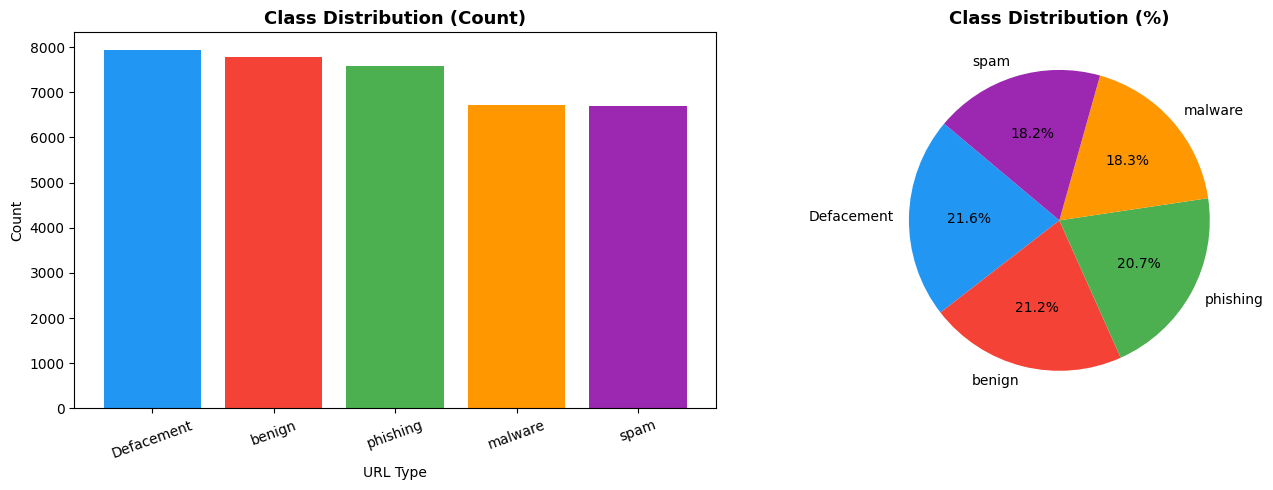

Classes: ['Defacement', 'benign', 'phishing', 'malware', 'spam']


In [7]:
# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df[TARGET].value_counts()
colors = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0']

axes[0].bar(counts.index, counts.values, color=colors[:len(counts)])
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('URL Type'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=colors[:len(counts)], startangle=140)
axes[1].set_title('Class Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(SAVE_DIR + 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Classes:', counts.index.tolist())

In [8]:
# Descriptive statistics for numeric features
numeric_df = df.select_dtypes(include=[np.number])
print(f'Numeric features: {numeric_df.shape[1]}')
numeric_df.describe().T.head(20)

Numeric features: 79


,count,mean,std,min,25%,50%,75%,max
Querylength,36707.0,21.908110,94.280669,0.0,0.0,0.0,19.0,1385.0
domain_token_count,36707.0,2.857439,0.906562,2.0,2.0,3.0,3.0,19.0
path_token_count,36707.0,8.954668,4.278406,0.0,6.0,8.0,11.0,68.0
avgdomaintokenlen,36707.0,5.401719,1.986858,1.5,4.0,5.0,6.5,29.5
longdomaintokenlen,36707.0,9.746016,4.856580,2.0,6.0,9.0,12.0,63.0
avgpathtokenlen,36427.0,4.556261,2.839388,0.0,3.0,4.1,5.0,105.0
tld,36707.0,2.857439,0.906562,2.0,2.0,3.0,3.0,19.0
charcompvowels,36707.0,14.976517,13.351315,0.0,7.0,13.0,19.0,193.0
charcompace,36707.0,10.216117,10.845807,0.0,5.0,8.0,12.0,142.0
ldl_url,36707.0,3.363909,13.447289,0.0,0.0,0.0,1.0,207.0


In [9]:
# NaN / -1 sentinel values
print('Cells with value -1 per feature (top 15):')
neg1_counts = (df == -1).sum().sort_values(ascending=False)
print(neg1_counts[neg1_counts > 0].head(15))

print('\nCells with NaN per feature (top 15):')
nan_counts = df.isnull().sum().sort_values(ascending=False)
print(nan_counts[nan_counts > 0].head(15))

Cells with value -1 per feature (top 15):
ISIpAddressInDomainName            36707
isPortEighty                       36693
SymbolCount_Afterpath              20481
Entropy_Afterpath                  20481
NumberRate_AfterPath               20481
LongestVariableValue               20285
Query_LetterCount                  20285
Query_DigitCount                   20285
delimeter_Count                    20285
Arguments_LongestWordLength        20285
Directory_DigitCount               11247
Directory_LetterCount              11247
SymbolCount_Directoryname          10320
sub-Directory_LongestWordLength     2051
SymbolCount_Extension               1855
dtype: int64

Cells with NaN per feature (top 15):
NumberRate_Extension        10130
Entropy_DirectoryName        8468
avgpathtokenlen               280
Entropy_Filename              236
Entropy_Extension              40
NumberRate_FileName            10
NumberRate_DirectoryName       10
Entropy_Afterpath               6
NumberRate_AfterPath

## 3 · Data Cleaning & Encoding

In [10]:
from sklearn.preprocessing import LabelEncoder

df_clean = df.copy()

# ── 3a. Drop constant / near-constant columns ──
nunique = df_clean.nunique()
const_cols = nunique[nunique <= 1].index.tolist()
print(f'Dropping {len(const_cols)} constant columns: {const_cols}')
df_clean.drop(columns=const_cols, inplace=True)

# ── 3b. Replace -1 sentinels with NaN, then impute with median ──
# -1 encodes 'not applicable' in this dataset
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if TARGET in num_cols: num_cols.remove(TARGET)

df_clean[num_cols] = df_clean[num_cols].replace(-1, np.nan)
for c in num_cols:
    median = df_clean[c].median()
    df_clean[c].fillna(median, inplace=True)

# ── 3c. Encode target ──
le = LabelEncoder()
df_clean['label'] = le.fit_transform(df_clean[TARGET])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# Save label encoder classes
import json
label_map = {int(v): k for k, v in zip(le.classes_, le.transform(le.classes_))}
with open(SAVE_DIR + 'label_map.json', 'w') as f:
    json.dump(label_map, f)

df_clean.drop(columns=[TARGET], inplace=True)
print(f'\nClean shape: {df_clean.shape}')

Dropping 1 constant columns: ['ISIpAddressInDomainName']
Label mapping: {'Defacement': np.int64(0), 'benign': np.int64(1), 'malware': np.int64(2), 'phishing': np.int64(3), 'spam': np.int64(4)}

Clean shape: (36707, 79)


## 4 · Feature Selection

Two-stage filter:
1. **Variance Threshold** — remove zero-variance features
2. **Correlation Filter** — drop one of each pair with |r| > 0.95
3. **RF Importance** — keep top-K features

Found infinite values in X. Replacing with NaN and then imputing with median.
After variance threshold: 77 features
Dropped 20 highly correlated features. Remaining: 57

Top 40 features selected by RF importance


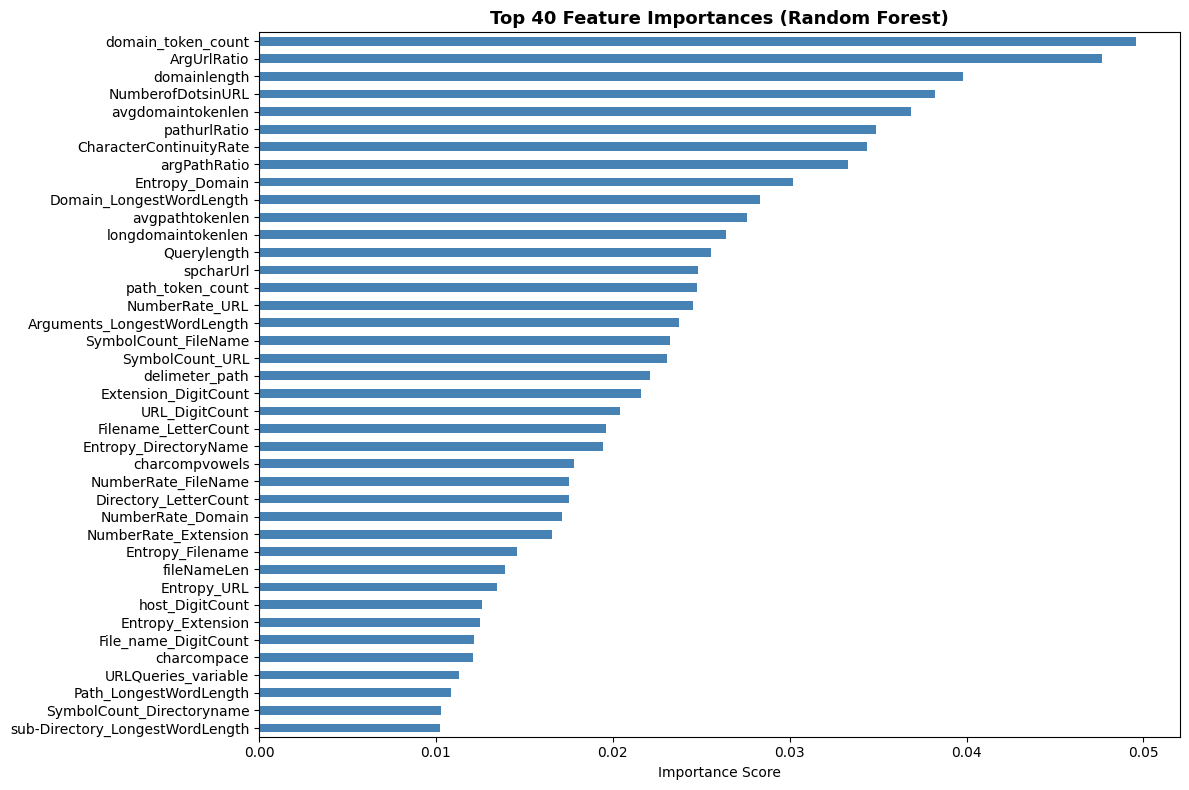

In [12]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['label'])
y = df_clean['label']

# Handle infinite values if any
if np.isinf(X).any().any():
    print("Found infinite values in X. Replacing with NaN and then imputing with median.")
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    # Impute NaNs created from infinite values, similar to how -1 was handled
    for col in X.columns:
        if X[col].isnull().any():
            median_val = X[col].median()
            X[col].fillna(median_val, inplace=True)

# ── Stage 1: Variance threshold ──
vt = VarianceThreshold(threshold=0.0)
vt.fit(X)
X = X[X.columns[vt.get_support()]]
print(f'After variance threshold: {X.shape[1]} features')

# ── Stage 2: Correlation filter ──
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [c for c in upper.columns if any(upper[c] > 0.95)]
X = X.drop(columns=to_drop_corr)
print(f'Dropped {len(to_drop_corr)} highly correlated features. Remaining: {X.shape[1]}')

# ── Stage 3: RF importance — top 40 features ──
TOP_K = 40
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

rf_sel = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_sel.fit(X_tr, y_tr)

importances = pd.Series(rf_sel.feature_importances_, index=X.columns)
top_features = importances.nlargest(TOP_K).index.tolist()
print(f'\nTop {TOP_K} features selected by RF importance')

# Plot importances
plt.figure(figsize=(12, 8))
importances[top_features].sort_values().plot(kind='barh', color='steelblue')
plt.title(f'Top {TOP_K} Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

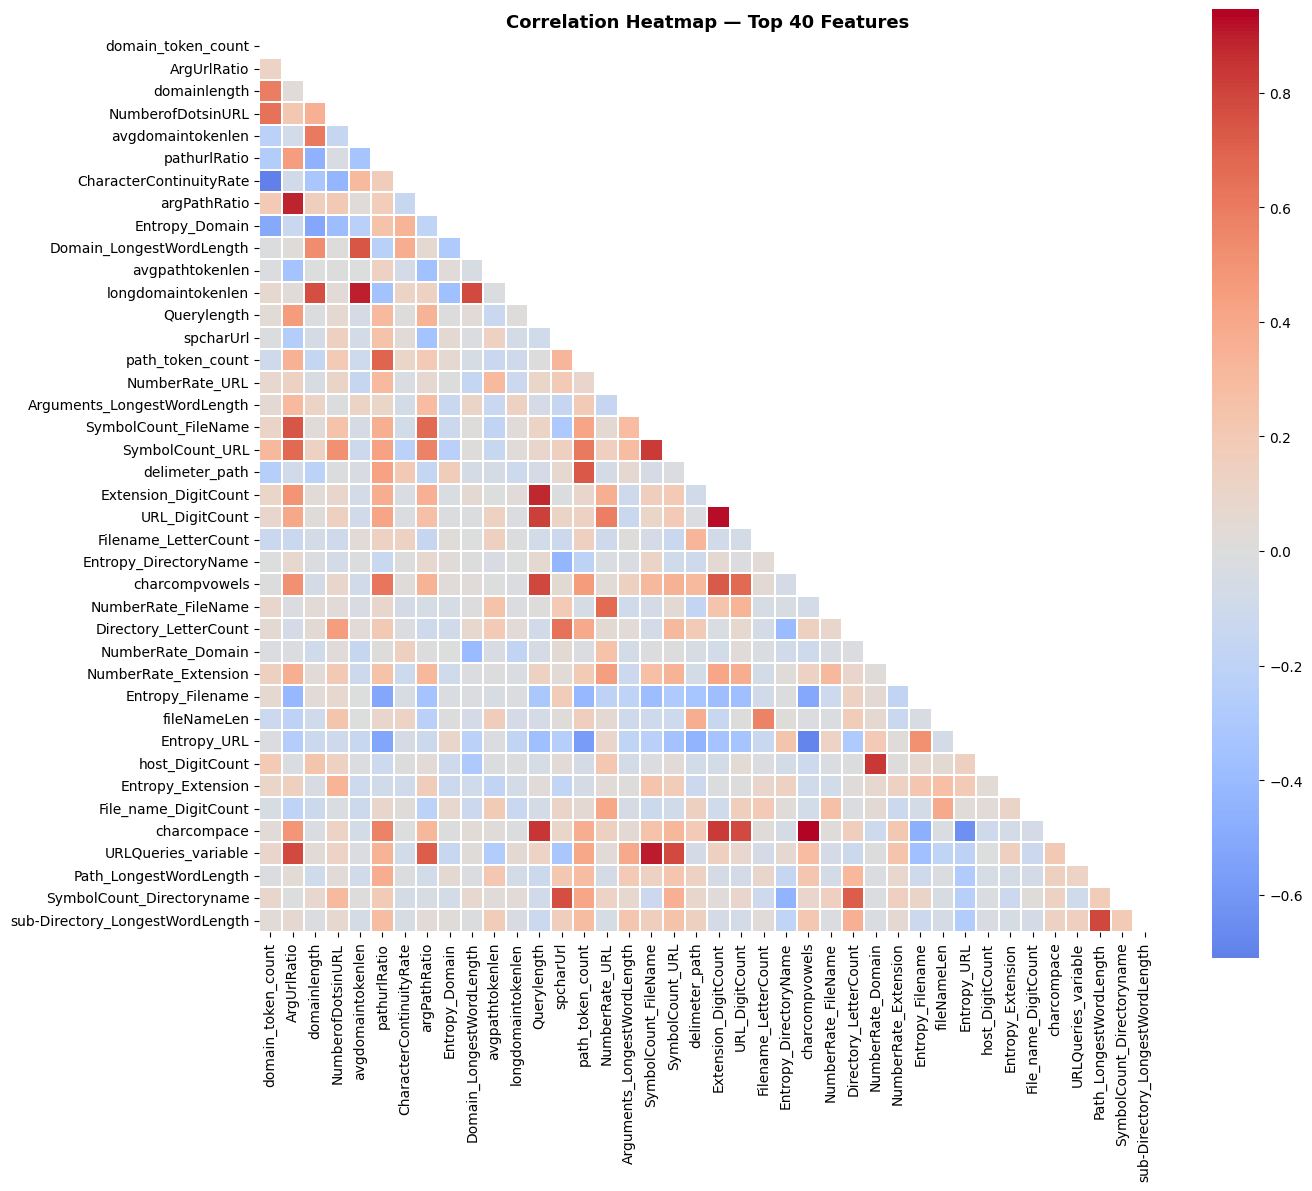

In [13]:
# Correlation heatmap of top features
plt.figure(figsize=(14, 12))
corr_top = X[top_features].corr()
mask = np.triu(np.ones_like(corr_top, dtype=bool))
sns.heatmap(corr_top, mask=mask, cmap='coolwarm', center=0, linewidths=0.3,
            annot=False, square=True, fmt='.1f')
plt.title('Correlation Heatmap — Top 40 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Save Processed Data

In [14]:
from sklearn.preprocessing import StandardScaler
import pickle

# Keep only selected features
X_sel = X[top_features].copy()
X_sel['label'] = y.values

# Save selected features list
with open(SAVE_DIR + 'top_features.json', 'w') as f:
    json.dump(top_features, f)

# Save full processed CSV
X_sel.to_csv(SAVE_DIR + 'processed_data.csv', index=False)

# Save scaler (fit on training split)
X_train_raw = X_sel.drop(columns=['label'])
scaler = StandardScaler()
scaler.fit(X_train_raw)
with open(SAVE_DIR + 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(SAVE_DIR + 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('✅ Saved to', SAVE_DIR)
print(f'   processed_data.csv : {X_sel.shape}')
print(f'   top_features.json  : {len(top_features)} features')
print(f'   scaler.pkl + label_encoder.pkl')

✅ Saved to /content/drive/MyDrive/ESI TPs/sec_miniProject/Detection_of_Malicious_URLs/output/
   processed_data.csv : (36707, 41)
   top_features.json  : 40 features
   scaler.pkl + label_encoder.pkl


In [15]:
# Final summary
print('=== PREPROCESSING SUMMARY ===')
print(f'Original features  : {df.shape[1]-1}')
print(f'Selected features  : {len(top_features)}')
print(f'Total samples      : {len(X_sel)}')
print(f'Class distribution :')
print(pd.Series(y).map(label_map).value_counts())

=== PREPROCESSING SUMMARY ===
Original features  : 79
Selected features  : 40
Total samples      : 36707
Class distribution :
label
Defacement    7930
benign        7781
phishing      7586
malware       6712
spam          6698
Name: count, dtype: int64
